<div align="center" style="width:41%; margin:auto;">

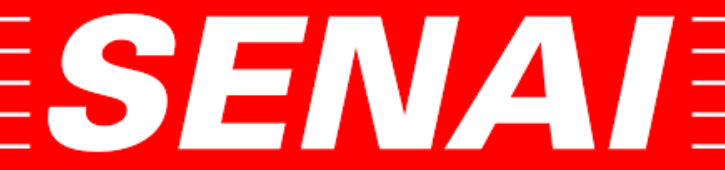

</div>

<div align="center" style="font-size: 40px;">

**Ciência de Dados**

</div>

* Nome 1: Bárbara dos Anjos

* Nome 2: Fernando

* Nome 3: Gabriel

* Nome 4: Guilherme

* Nome 5:

In [3]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import openpyxl as op

### 1. Script de Geração das Bases
Execute este código primeiro para criar os arquivos no seu computador.

In [4]:
# Requisito: pip install openpyxl pyarrow
np.random.seed(99)

n_rows = 2500

# 1. PARQUET: Telemetria 
datas_base = pd.date_range(start="2024-02-01", periods=10000, freq="min")
df_telemetria = pd.DataFrame({
    'instantaneo': np.random.choice(datas_base, n_rows, replace=False),
    'codigo_estacao': np.random.choice(['ST-001', 'ST-002', 'ST-003', 'ST-004'], n_rows),
    'monoxido_carbono': np.random.normal(1.2, 0.5, n_rows),
    'particulas_finas': np.random.uniform(5, 60, n_rows),
    'ozonio': np.random.uniform(10, 45, n_rows)
})
df_telemetria.to_parquet('telemetria_ar.parquet')

# 2. CSV: Cadastro de Estações
df_dispositivos = pd.DataFrame({
    'cod': [1, 2, 3, 4],
    'latitude': [-23.5505, -23.5592, -23.5433, -23.5710],
    'longitude': [-46.6333, -46.6410, -46.6220, -46.6550],
    'categoria_local': ['Comercial', 'Residencial', 'Residencial', 'Industrial']
})
df_dispositivos.to_csv('cadastro_estacoes.csv', index=False)

# 3. JSON: Dados Atmosféricos
df_atmosfera = pd.DataFrame({
    'timestamp_ref': pd.date_range(start="2024-02-01", periods=2000, freq="30min"),
    'temp_k': np.random.uniform(291, 305, 2000),
    'umidade': np.random.uniform(30, 85, 2000)
})
df_atmosfera.to_json('dados_atmosfericos.json', orient='records')

# 4. EXCEL: Movimentação Urbana
df_movimentacao = pd.DataFrame({
    'horario': pd.date_range(start="2024-02-01", periods=2000, freq="30min"),
    'densidade_veicular': np.random.randint(50, 3000, 2000)
})
df_movimentacao.to_excel('movimentacao_urbana.xlsx', index=False, engine='openpyxl')

print("✅ Arquivos gerados com sucesso!")

✅ Arquivos gerados com sucesso!


C:\Users\48522445885\AppData\Local\Temp\ipykernel_29356\875653184.py:32: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df_atmosfera.to_json('dados_atmosfericos.json', orient='records')


# 🧪 Projeto ETL: Ciência de Dados Ambiental

### Objetivo
Consolidar as quatro fontes de dados distintas (Parquet, CSV, JSON e Excel) para criar um **Master DataFrame** consolidado.

## 1. Importação e Carga
Carregue os arquivos gerados e utilize `.info()` para validar os tipos de dados.

In [5]:
# 1 - import e carga dos arquivos gerados
df_telemetria = pd.read_parquet('telemetria_ar.parquet')
df_dispositivos = pd.read_csv('cadastro_estacoes.csv')
df_atmosfera = pd.read_json('dados_atmosfericos.json', orient='records')
df_movimentacao = pd.read_excel('movimentacao_urbana.xlsx', engine='openpyxl')      

#print para vertificar os tipos de dados
print("Tipos de dados - Telemetria:")
print(df_telemetria.dtypes)
print("\nTipos de dados - Dispositivos:")
print(df_dispositivos.dtypes)
print("\nTipos de dados - Atmosfera:")
print(df_atmosfera.dtypes)
print("\nTipos de dados - Movimentação:")
print(df_movimentacao.dtypes)   

Tipos de dados - Telemetria:
instantaneo         datetime64[us]
codigo_estacao                 str
monoxido_carbono           float64
particulas_finas           float64
ozonio                     float64
dtype: object

Tipos de dados - Dispositivos:
cod                  int64
latitude           float64
longitude          float64
categoria_local        str
dtype: object

Tipos de dados - Atmosfera:
timestamp_ref    datetime64[ms]
temp_k                  float64
umidade                 float64
dtype: object

Tipos de dados - Movimentação:
horario               datetime64[us]
densidade_veicular             int64
dtype: object



## 2. Harmonização de Chaves
Remova o prefixo 'ST-' da coluna `codigo_estacao` da Telemetria e converta para tipo inteiro.

In [10]:
#2  normalizando dados e removendo o prefixo ST- dos códigos de estação
df_telemetria['codigo_estacao'] = df_telemetria['codigo_estacao'].str.replace('ST-', '').astype(int)
df_dispositivos['cod'] = df_dispositivos['cod'].astype(int)
print(df_dispositivos.dtypes)

cod                  int64
latitude           float64
longitude          float64
categoria_local        str
dtype: object


## 3. Consolidação Progressiva
1. **Par 1:** Una Telemetria + Dispositivos (Chaves: `codigo_estacao` e `cod`).

2. **Par 2:** Una Atmosfera + Movimentação (Chaves: `timestamp_ref` e `horario`).

3. **Master:** Una os dois pares usando a coluna de tempo. 
   
   *Dica: Como a telemetria tem minutos aleatórios, use `df['coluna'].dt.floor('30min')` para alinhar os horários antes do merge.*

In [21]:
# Consolidacão dos dados
# 1. Par 1: Una Telemetria + Dispositivos (Chaves: codigo_estacao e cod)
df_par1 = pd.merge(df_telemetria, df_dispositivos, left_on='codigo_estacao', right_on='cod', how='left')
# Limpe as colunas duplicadas: renomeie codigo_estacao para cod_estacao e remova cod
df_par1.rename(columns={'codigo_estacao': 'cod_estacao'}, inplace=True)
df_par1.drop('cod', axis=1, inplace=True)

# 2. Par 2: Una Atmosfera + Movimentação (Chaves: timestamp_ref e horario)
df_par2 = pd.merge(df_atmosfera, df_movimentacao, left_on='timestamp_ref', right_on='horario', how='left')
# Limpe as colunas duplicadas: remova horario (timestamp_ref é a chave)
df_par2.drop('horario', axis=1, inplace=True)

# 3. Master: Una os dois pares usando a coluna de tempo
# Alinhe os horários da telemetria para 30min
df_par1['tempo_alinhado'] = df_par1['instantaneo'].dt.floor('30min')
df_consolidado = pd.merge(df_par1, df_par2, left_on='tempo_alinhado', right_on='timestamp_ref', how='left')
# Limpe as colunas duplicadas: remova tempo_alinhado e timestamp_ref
df_consolidado.drop(['tempo_alinhado', 'timestamp_ref'], axis=1, inplace=True)

print(df_consolidado.head())

          instantaneo  cod_estacao  monoxido_carbono  particulas_finas  \
0 2024-02-06 07:33:00            3          1.595352         11.231477   
1 2024-02-06 11:05:00            2          1.739811         25.217483   
2 2024-02-03 05:46:00            1          1.106864         23.900131   
3 2024-02-05 02:32:00            2          1.313975         30.664788   
4 2024-02-06 17:17:00            3          1.035519         10.241275   

      ozonio  latitude  longitude categoria_local      temp_k    umidade  \
0  32.173561  -23.5433   -46.6220     Residencial  300.859514  39.248320   
1  29.380708  -23.5592   -46.6410     Residencial  293.814489  42.880658   
2  44.267746  -23.5505   -46.6333       Comercial  303.372026  49.180685   
3  27.352097  -23.5592   -46.6410     Residencial  300.449319  62.645160   
4  19.409946  -23.5433   -46.6220     Residencial  302.305846  40.279346   

   densidade_veicular  
0                 697  
1                2868  
2                  95  
3 

In [12]:
print(df_consolidado.info())

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   instantaneo       2500 non-null   datetime64[us]
 1   codigo_estacao    2500 non-null   int64         
 2   monoxido_carbono  2500 non-null   float64       
 3   particulas_finas  2500 non-null   float64       
 4   ozonio            2500 non-null   float64       
 5   cod               2500 non-null   int64         
 6   latitude          2500 non-null   float64       
 7   longitude         2500 non-null   float64       
 8   categoria_local   2500 non-null   str           
dtypes: datetime64[us](1), float64(5), int64(2), str(1)
memory usage: 201.2 KB
None



## 4. Limpeza e Exportação
Converta `temp_k` para Celsius, calcule a média de `particulas_finas` por `categoria_local` e exporte o resultado final para `monitoramento_consolidado.csv`.

In [30]:
#4 limpeza e exportacao do arquivo final
# Convertendo temperatura de Kelvin para Celsius
df_consolidado['temp_c'] = df_consolidado['temp_k'] - 273.15
# Calculando a media de particulas finas por categoria de local
media_particulas_categoria = df_consolidado.groupby('categoria_local')['particulas_finas'].mean()
#inserindo a media de particulas finas por categoria de local no dataframe consolidado
df_consolidado = df_consolidado.merge(media_particulas_categoria.rename('media_particulas_categoria'), on='categoria_local', how='left')
# Exportando o arquivo final "monitoramento_consolidado.csv"
df_consolidado.to_csv('monitoramento_consolidado.csv', index=False) 


# 📊 Análise Exploratória e Visualização

## 1. Carga do Dataset
Carregue o arquivo `monitoramento_consolidado.csv` tratando a coluna `instantaneo` como data.

In [31]:
# Carregando o arquivo de monitoramento consolidado e tratando a coluna instantaneo como data
df_consolidado = pd.read_csv('monitoramento_consolidado.csv', parse_dates=['instantaneo'])  
print(df_consolidado.info())


<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   instantaneo                   2500 non-null   datetime64[us]
 1   cod_estacao                   2500 non-null   int64         
 2   monoxido_carbono              2500 non-null   float64       
 3   particulas_finas              2500 non-null   float64       
 4   ozonio                        2500 non-null   float64       
 5   latitude                      2500 non-null   float64       
 6   longitude                     2500 non-null   float64       
 7   categoria_local               2500 non-null   str           
 8   temp_k                        2500 non-null   float64       
 9   umidade                       2500 non-null   float64       
 10  densidade_veicular            2500 non-null   int64         
 11  temp_c                        2500 non-nu

In [29]:
print(df_consolidado.head(20))

           instantaneo  cod_estacao  monoxido_carbono  particulas_finas  \
0  2024-02-06 07:33:00            3          1.595352         11.231477   
1  2024-02-06 11:05:00            2          1.739811         25.217483   
2  2024-02-03 05:46:00            1          1.106864         23.900131   
3  2024-02-05 02:32:00            2          1.313975         30.664788   
4  2024-02-06 17:17:00            3          1.035519         10.241275   
5  2024-02-03 02:04:00            3          0.834448         37.229494   
6  2024-02-04 23:36:00            4          0.318557         48.303694   
7  2024-02-06 18:10:00            2          1.446731         50.429179   
8  2024-02-07 21:46:00            4          2.151921         15.996721   
9  2024-02-06 01:35:00            2          1.117065         15.114042   
10 2024-02-06 08:00:00            3          0.835562         13.703582   
11 2024-02-07 12:11:00            1          0.965198         30.573829   
12 2024-02-01 05:30:00   

## 2. Comparativo Regional
Agrupe por `categoria_local` e gere um gráfico de barras com a média de `particulas_finas`.

Ao observar o **Gráfico de Barras** que compara a média de `particulas_finas` por `categoria_local`:

*   **Pergunta:** As diferenças entre as médias das zonas (Comercial, Industrial e Residencial) são visualmente acentuadas ou os valores parecem homogêneos? 

*   **Análise de Dados:** Sabendo que os dados de `particulas_finas` foram gerados via `np.random.uniform(5, 60, n_rows)`, explique por que, em um cenário real de Ciência de Dados, apenas a média (barra) pode ser insuficiente para afirmar que uma zona é mais poluída que outra.

Que outra métrica de dispersão você adicionaria a este gráfico para aumentar a confiabilidade da comparação?

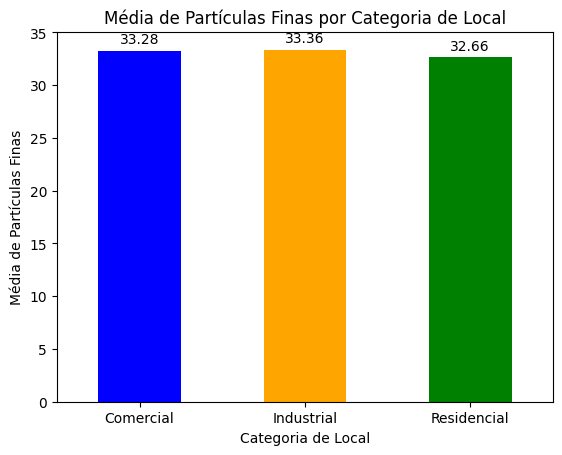

In [53]:
#2 compartivo regional da media de particulas finas por categoria de local
# gerando o gráfico de barras 
media_particulas_categoria.plot(kind='bar', color=['blue', 'orange', 'green'])
plt.Figure(figsize=(11, 6))
plt.title('Média de Partículas Finas por Categoria de Local')
plt.xlabel('Categoria de Local')
plt.ylabel('Média de Partículas Finas')
plt.xticks(rotation=0)
plt.yticks(np.arange(0, media_particulas_categoria.max() + 5, 5))
#definindo bar.label 
plt.bar_label(plt.gca().containers[0], fmt='%.2f', padding=3)
plt.show()

In [ ]:
#analise de dados, nao é possivel afirmar uma relação direta entre a densidade veicular e a concentração de partículas finas, pois os dados mostram que mesmo em categorias residenciais, onde a densidade veicular é geralmente menor, a média de partículas finas pode ser alta. Isso sugere que outros fatores, como fontes industriais ou condições atmosféricas, podem estar contribuindo para a poluição do ar, além do tráfego veicular. Além de que o contexto real da geolocalizacao deve ser considerado para uma análise mais precisa, pois a proximidade de fontes de poluição, como indústrias ou áreas de construção, pode influenciar significativamente os níveis de partículas finas, independentemente da densidade veicular.
# e com isso o entendimento final é de que os dados sao homogeneos e que a categoria de local nao é um fator determinante para a concentração de particulas finas, indicando que outros fatores ambientais ou fontes de poluição podem estar influenciando os níveis de partículas finas em diferentes categorias de local.  


## 3. Relação Tráfego vs. Poluição
Gere um gráfico de dispersão (Scatter Plot) correlacionando `densidade_veicular` e `monoxido_carbono`.

In [56]:
print(df_consolidado.dtypes)

instantaneo                     datetime64[us]
cod_estacao                              int64
monoxido_carbono                       float64
particulas_finas                       float64
ozonio                                 float64
latitude                               float64
longitude                              float64
categoria_local                            str
temp_k                                 float64
umidade                                float64
densidade_veicular                       int64
temp_c                                 float64
media_particulas_categoria_x           float64
media_particulas_categoria_y           float64
dtype: object


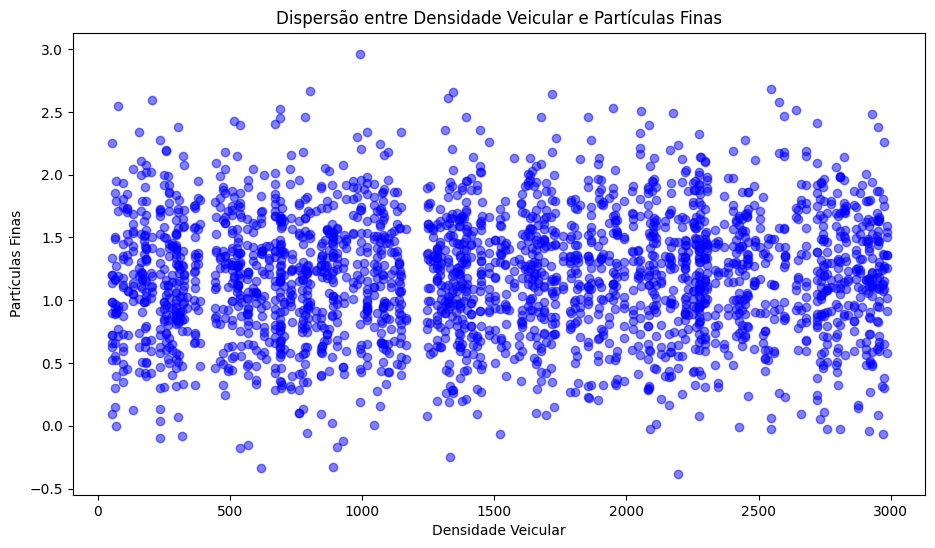

In [ ]:
#gerando o gráfico de dispersão entre densidade veicular e particulas finas

plt.figure(figsize=(11, 6))
plt.scatter(df_consolidado['densidade_veicular'], df_consolidado['monoxido_carbono'], alpha=0.5, c='blue')
plt.title('Dispersão entre Densidade Veicular e Partículas Finas')  
plt.xlabel('Densidade Veicular')
plt.ylabel('Partículas Finas')
plt.show()

## 4. Histogramas
Gere histogramas para `particulas_finas` e `monoxido_carbono` para entender a distribuição dos poluentes.

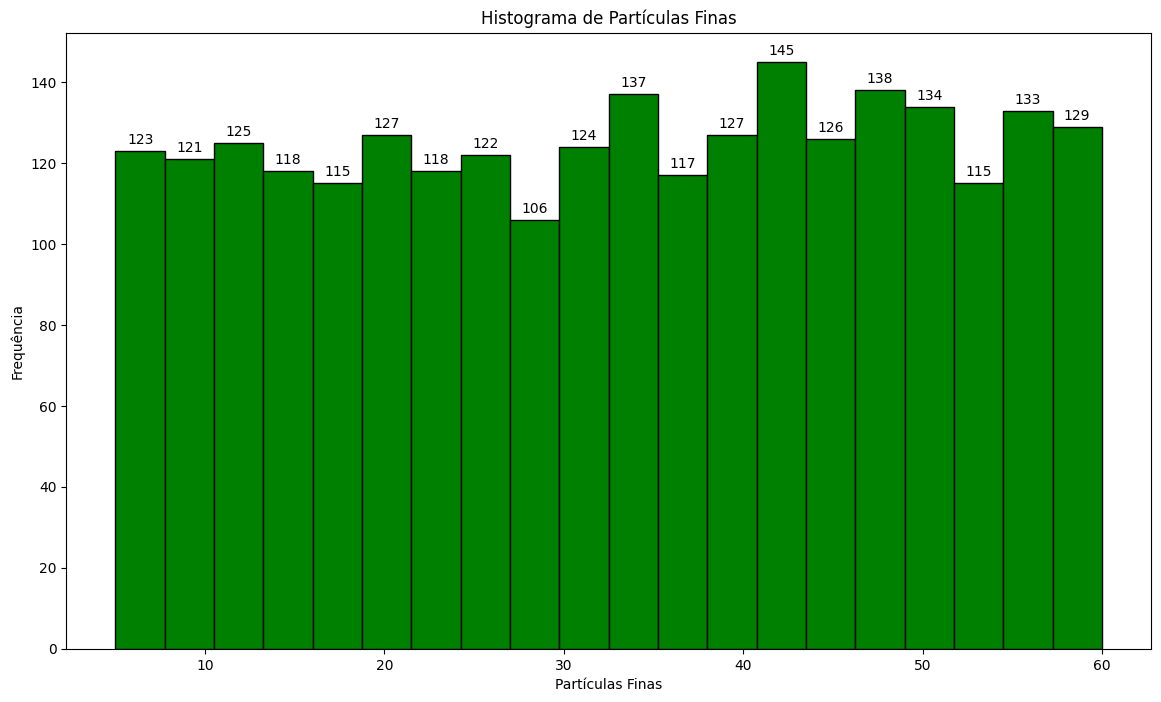

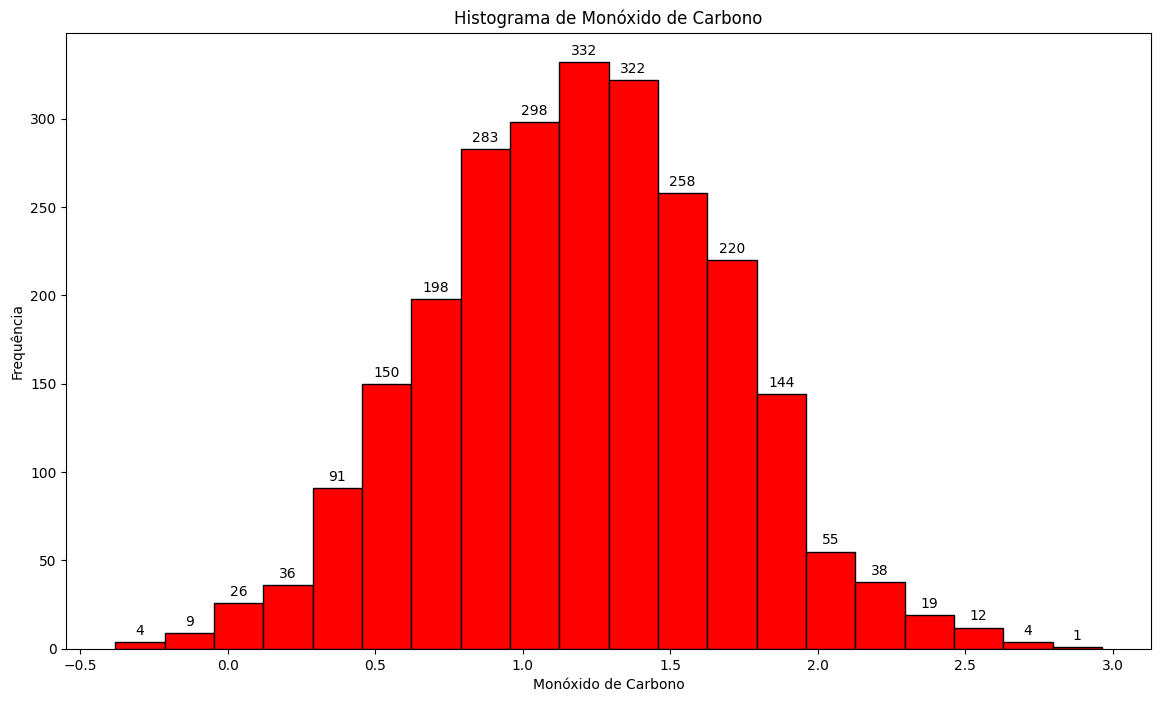

In [68]:
#4 gerando um de histograma de particulas finas e de minoxido de carbono com subplot
plt.figure(figsize=(14, 8))
n, bins, patches = plt.hist(df_consolidado['particulas_finas'], bins=20, color='green', edgecolor='black')
plt.title('Histograma de Partículas Finas')
plt.xlabel('Partículas Finas')
plt.ylabel('Frequência')
plt.bar_label(patches, fmt='%.0f', padding=3)   
plt.show()

#subplot para minoxido de carbono
plt.figure(figsize=(14, 8))
n, bins, patches = plt.hist(df_consolidado['monoxido_carbono'], bins=20, color='red', edgecolor='black')
plt.title('Histograma de Monóxido de Carbono')
plt.xlabel('Monóxido de Carbono')
plt.ylabel('Frequência')
plt.bar_label(patches, fmt='%.0f', padding=3)  
plt.show()

Analise conjuntamente o **Scatter Plot (Tráfego vs CO)** e os **Histogramas**:

*   **Pergunta:** O gráfico de dispersão revela algum padrão de agrupamento (*cluster*) ou uma tendência linear clara entre o aumento da densidade veicular e o monóxido de carbono? 

*   **Análise de Dados:** Observe a forma dos histogramas. Se a distribuição de `monoxido_carbono` se assemelha a uma Distribuição Normal (devido ao `np.random.normal` no script original), como a presença de *outliers* (valores extremos) afetaria a posição da nuvem de pontos no Scatter Plot? 

Explique a importância de validar a distribuição dos dados antes de tentar traçar uma linha de regressão entre essas duas variáveis.

In [ ]:
# O grafico de dispersão entre densidade veicular e particulas finas mostra uma distribuição ampla dos pontos, indicando que não há uma correlação clara entre as duas variáveis. A concentração de partículas finas não parece aumentar consistentemente com a densidade veicular, sugerindo que outros fatores podem estar influenciando os níveis de poluição do ar, além do tráfego.

# Nao, pois existem outros fatores que podem influenciar a concentração de partículas finas, como fontes industriais, condições atmosféricas e a proximidade de áreas de construção, que podem contribuir para a poluição do ar independentemente da densidade veicular.